<a href="https://colab.research.google.com/github/songyanzhu/gges/blob/main/2526-GGES6020/Practical4_Pythonic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [176]:
!pip install scitbx --quiet

import shutil
from pathlib import Path
from pyproj import CRS
import geopandas as gpd
from scitbx import google

root = google.mount_drive()
root_proj = root.joinpath("gges6020")
print(root_proj)

# root_proj.exists()

/content/drive/My Drive/gges6020


In [138]:
dir_in = root_proj.joinpath('data')
assert dir_in.exists(), f'{dir_in} NOT exists'
dir_out = root_proj.joinpath('output')
dir_out.mkdir(exist_ok = True, parents = True)

In [139]:
list(dir_in.glob('*'))

[PosixPath('/content/drive/My Drive/gges6020/data/HTI_adm3.sbn'),
 PosixPath('/content/drive/My Drive/gges6020/data/HTI_adm3.sbx'),
 PosixPath('/content/drive/My Drive/gges6020/data/HTI_adm3.shx'),
 PosixPath('/content/drive/My Drive/gges6020/data/HTI_adm3.dbf'),
 PosixPath('/content/drive/My Drive/gges6020/data/HTI_adm3.shp'),
 PosixPath('/content/drive/My Drive/gges6020/data/DOM_adm0.prj'),
 PosixPath('/content/drive/My Drive/gges6020/data/DOM_adm0.sbn'),
 PosixPath('/content/drive/My Drive/gges6020/data/DOM_adm0.sbx'),
 PosixPath('/content/drive/My Drive/gges6020/data/DOM_adm0.shp'),
 PosixPath('/content/drive/My Drive/gges6020/data/DOM_adm0.dbf'),
 PosixPath('/content/drive/My Drive/gges6020/data/DOM_adm0.shx'),
 PosixPath('/content/drive/My Drive/gges6020/data/DOM_adm0.shp.xml'),
 PosixPath('/content/drive/My Drive/gges6020/data/Matthew_WGS84.dbf'),
 PosixPath('/content/drive/My Drive/gges6020/data/Matthew_WGS84.sbn'),
 PosixPath('/content/drive/My Drive/gges6020/data/Matthew_WGS8

In [140]:
for p_in in dir_in.glob('HTI_adm3.*'):
    p_out = dir_out.joinpath(p_in.name)
    print(p_out)
    shutil.copy(p_in, p_out)

/content/drive/My Drive/gges6020/output/HTI_adm3.sbn
/content/drive/My Drive/gges6020/output/HTI_adm3.sbx
/content/drive/My Drive/gges6020/output/HTI_adm3.shx
/content/drive/My Drive/gges6020/output/HTI_adm3.dbf
/content/drive/My Drive/gges6020/output/HTI_adm3.shp
/content/drive/My Drive/gges6020/output/HTI_adm3.prj
/content/drive/My Drive/gges6020/output/HTI_adm3.shp.xml


In [141]:
for p in dir_out.glob('HTI_adm3.*'):
    print(p)
    p.unlink()

/content/drive/My Drive/gges6020/output/HTI_adm3.sbn
/content/drive/My Drive/gges6020/output/HTI_adm3.sbx
/content/drive/My Drive/gges6020/output/HTI_adm3.shx
/content/drive/My Drive/gges6020/output/HTI_adm3.dbf
/content/drive/My Drive/gges6020/output/HTI_adm3.shp
/content/drive/My Drive/gges6020/output/HTI_adm3.prj
/content/drive/My Drive/gges6020/output/HTI_adm3.shp.xml


<Axes: >

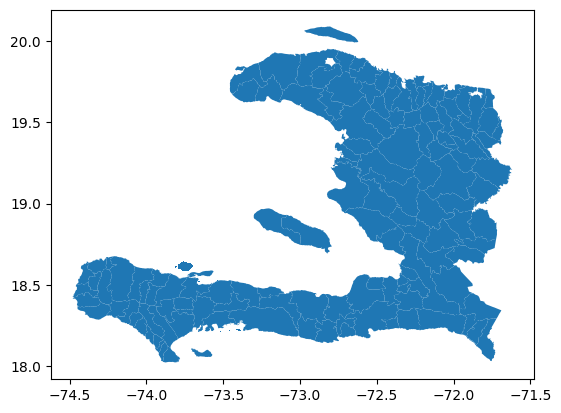

In [142]:
p_admin_src = dir_in.joinpath('HTI_adm3.shp')
if not p_admin_src.exists(): raise FileNotFoundError(f"File not found: {p_admin_src}")

admin_gdf = gpd.read_file(p_admin_src)
admin_gdf.plot()

In [143]:
p_admin_tar = dir_out.joinpath('HTI_adm3.shp')
print(f"Checking if 'admin_tar' exists: {p_admin_tar.exists()}")
admin_gdf.to_file(p_admin_tar)
print(f"Checking if 'admin_tar' exists again: {p_admin_tar.exists()}")

Checking if 'admin_tar' exists: False
Checking if 'admin_tar' exists again: True


In [144]:
print(admin_gdf.crs)

EPSG:4326


In [145]:
# # If your data is in WGS84 lat/lon
# admin_gdf = admin_gdf.set_crs("EPSG:4326")  # only if CRS not already defined

# Reproject to UTM Zone 18N
admin_utm = admin_gdf.to_crs("EPSG:32618")

p_UTM = dir_in.joinpath("WGS_1984_UTM_Zone_18.5N.prj")
UTM = CRS.from_wkt(open(p_UTM).read())
admin_utm = admin_gdf.to_crs(UTM)

p_admin_utm = dir_out.joinpath("HTI_adm3_UTM.shp")
admin_utm.to_file(p_admin_utm)

In [158]:
admin_utm['Adm_Area'] = admin_utm.area / 1e4
admin_utm['Pop_Den'] = admin_utm['ADMINPOP'] / admin_utm['Adm_Area']

In [159]:
p_matt_src = dir_in.joinpath('Matthew_WGS84.shp')
p_matt_tar = dir_out.joinpath('Matthew_WGS84.shp')
p_matt_utm = dir_out.joinpath("Matthew_UTM.shp")
matt_gdf = gpd.read_file(p_matt_src)

matt_utm = matt_gdf.to_crs(UTM)
matt_gdf.to_file(p_matt_tar)
matt_utm.to_file(p_matt_utm)

In [160]:
for p in dir_out.glob('*'):
    print(p)
    p.unlink()

/content/drive/My Drive/gges6020/output/Haiti_admin_Matt_intersect.shp
/content/drive/My Drive/gges6020/output/Haiti_admin_Matt_intersect.shx
/content/drive/My Drive/gges6020/output/Haiti_admin_Matt_intersect.dbf
/content/drive/My Drive/gges6020/output/Haiti_admin_Matt_intersect.cpg
/content/drive/My Drive/gges6020/output/Haiti_admin_Matt_intersect.prj
/content/drive/My Drive/gges6020/output/Matthew_WGS84.shp
/content/drive/My Drive/gges6020/output/Matthew_WGS84.shx
/content/drive/My Drive/gges6020/output/Matthew_WGS84.dbf
/content/drive/My Drive/gges6020/output/Matthew_WGS84.cpg
/content/drive/My Drive/gges6020/output/Matthew_WGS84.prj
/content/drive/My Drive/gges6020/output/Matthew_UTM.shp
/content/drive/My Drive/gges6020/output/Matthew_UTM.shx
/content/drive/My Drive/gges6020/output/Matthew_UTM.dbf
/content/drive/My Drive/gges6020/output/Matthew_UTM.cpg
/content/drive/My Drive/gges6020/output/Matthew_UTM.prj


<Axes: >

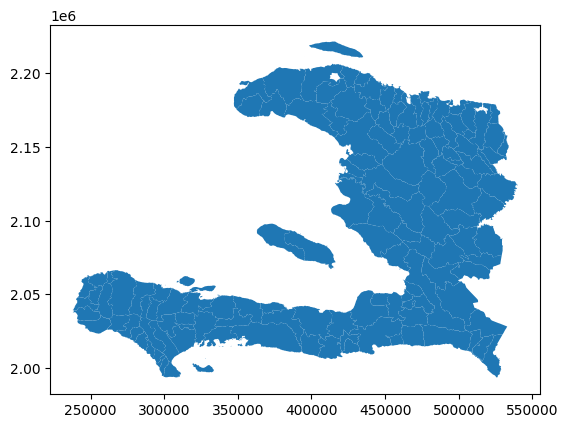

In [161]:
admin_utm.plot()

<Axes: >

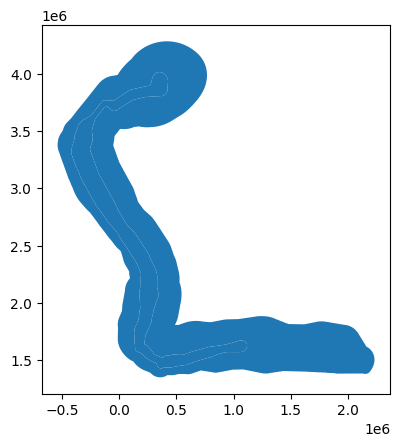

In [162]:
matt_utm.plot()

<Axes: >

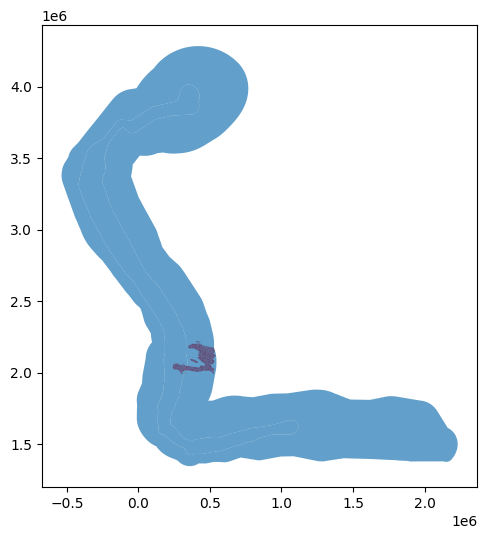

In [163]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize = (8, 6))
admin_utm.plot(ax = ax, facecolor = 'red')
matt_utm.plot(ax = ax, alpha = 0.7)

In [164]:
assert admin_utm.crs == matt_utm.crs, f'ERROR: mismatch project! \n admin_utm: {admin_utm.crs} \n matt_utm: {matt_utm.crs}'

In [171]:
admin_matt_utm_intersect = gpd.overlay(admin_utm, matt_utm, how="intersection", keep_geom_type = True)
# admin_utm.geometry.intersection(matt_utm.union_all())

<Axes: >

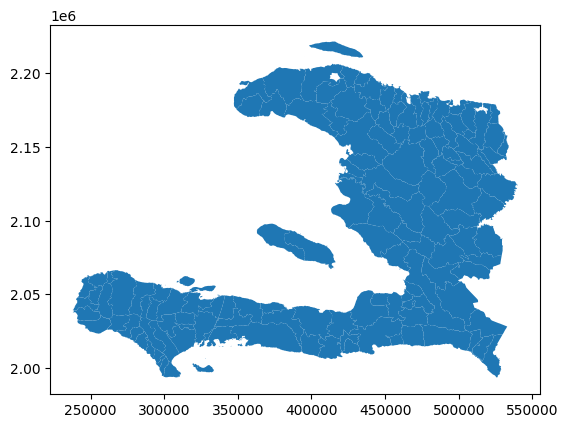

In [172]:
admin_matt_utm_intersect.plot()

In [173]:
admin_matt_utm_intersect['Aff_Area'] = admin_matt_utm_intersect.area / 1e4

admin_matt_utm_intersect['Aff_Pop'] = admin_matt_utm_intersect['Pop_Den'] * admin_matt_utm_intersect['Aff_Area']

In [177]:
p_admin_matt_utm_intersect = dir_out.joinpath("Haiti_admin_Matt_intersect.shp")
admin_matt_utm_intersect.to_file(p_admin_matt_utm_intersect)